In [2]:
import os
from plotnine import *
import polars as pl
import pandas as pd
import pairadigm as pdm

In [3]:
# Fix all_tables_item_scores.csv

DIRECTORIES = [
    "gilbert_meta_2", 
    "gilbert_meta_102", 
    "gilbert_meta_103",
    "gilbert_meta_104"
]

all_tables_item_scores_dfs = []
for dir in DIRECTORIES:
    df = pd.read_csv(f"../results/{dir}/{dir}_all_item_scores.csv")
    all_tables_item_scores_dfs.append(df)

all_tables_item_scores_df = pd.concat(all_tables_item_scores_dfs, ignore_index=True)
all_tables_item_scores_df.to_csv("../results/all_tables_item_scores.csv", index=False)

In [4]:
all_tables_item_scores_df.columns

Index(['item', 'section_prompt', 'item_text', 'combined_text',
       'CGCoT_Breakdown_gemini-3-flash-preview',
       'CGCoT_Breakdown_gpt-5.4-mini',
       'Bradley_Terry_Score_gemini-3-flash-preview',
       'Bradley_Terry_SE_gemini-3-flash-preview',
       'Bradley_Terry_Score_gpt-5.4-mini', 'Bradley_Terry_SE_gpt-5.4-mini',
       'a', 'b', 'table'],
      dtype='str')

In [44]:
all_tables_item_scores_df_long = (
    pd.wide_to_long(
        all_tables_item_scores_df,
        stubnames=["Bradley_Terry_Score", "Bradley_Terry_SE"],
        i=["item", "table", "a", "b"],  # keep these fixed
        j="model",                              # model/table name extracted here
        sep="_",
        suffix=".+",                            # allows names like gemini-3-flash-preview
    )
    .reset_index()
    .rename(
        columns={
            "Bradley_Terry_Score": "score",
            "Bradley_Terry_SE": "SE",
        }
    )
)

all_tables_item_scores_df_long.head()

,item,table,a,b,model,CGCoT_Breakdown_gemini-3-flash-preview,CGCoT_Breakdown_gpt-5.4-mini,combined_text,item_text,section_prompt,score,SE
0,20,gilbert_meta_2,2.039108,-0.495678,gemini-3-flash-preview,Original Text: Teacher Directions to Read Alou...,Original Text: Teacher Directions to Read Alou...,Teacher Directions to Read Aloud: “Now you wil...,What is similar about the work that paleontolo...,Teacher Directions to Read Aloud: “Now you wil...,3.000000,4.003638
1,20,gilbert_meta_2,2.039108,-0.495678,gpt-5.4-mini,Original Text: Teacher Directions to Read Alou...,Original Text: Teacher Directions to Read Alou...,Teacher Directions to Read Aloud: “Now you wil...,What is similar about the work that paleontolo...,Teacher Directions to Read Aloud: “Now you wil...,0.527728,0.958699
2,15,gilbert_meta_2,3.282003,-0.556399,gemini-3-flash-preview,Original Text: Teacher Directions to Read Alou...,Original Text: Teacher Directions to Read Alou...,Teacher Directions to Read Aloud: “Now you wil...,"According to the passage, who uses clues to fi...",Teacher Directions to Read Aloud: “Now you wil...,-3.000000,0.109184
3,15,gilbert_meta_2,3.282003,-0.556399,gpt-5.4-mini,Original Text: Teacher Directions to Read Alou...,Original Text: Teacher Directions to Read Alou...,Teacher Directions to Read Aloud: “Now you wil...,"According to the passage, who uses clues to fi...",Teacher Directions to Read Aloud: “Now you wil...,-2.979776,0.180543
4,19,gilbert_meta_2,1.492890,-0.170499,gemini-3-flash-preview,Original Text: Teacher Directions to Read Alou...,Original Text: Teacher Directions to Read Alou...,Teacher Directions to Read Aloud: “Now you wil...,What is one reason people want to find ancestors?,Teacher Directions to Read Aloud: “Now you wil...,0.386963,0.627291


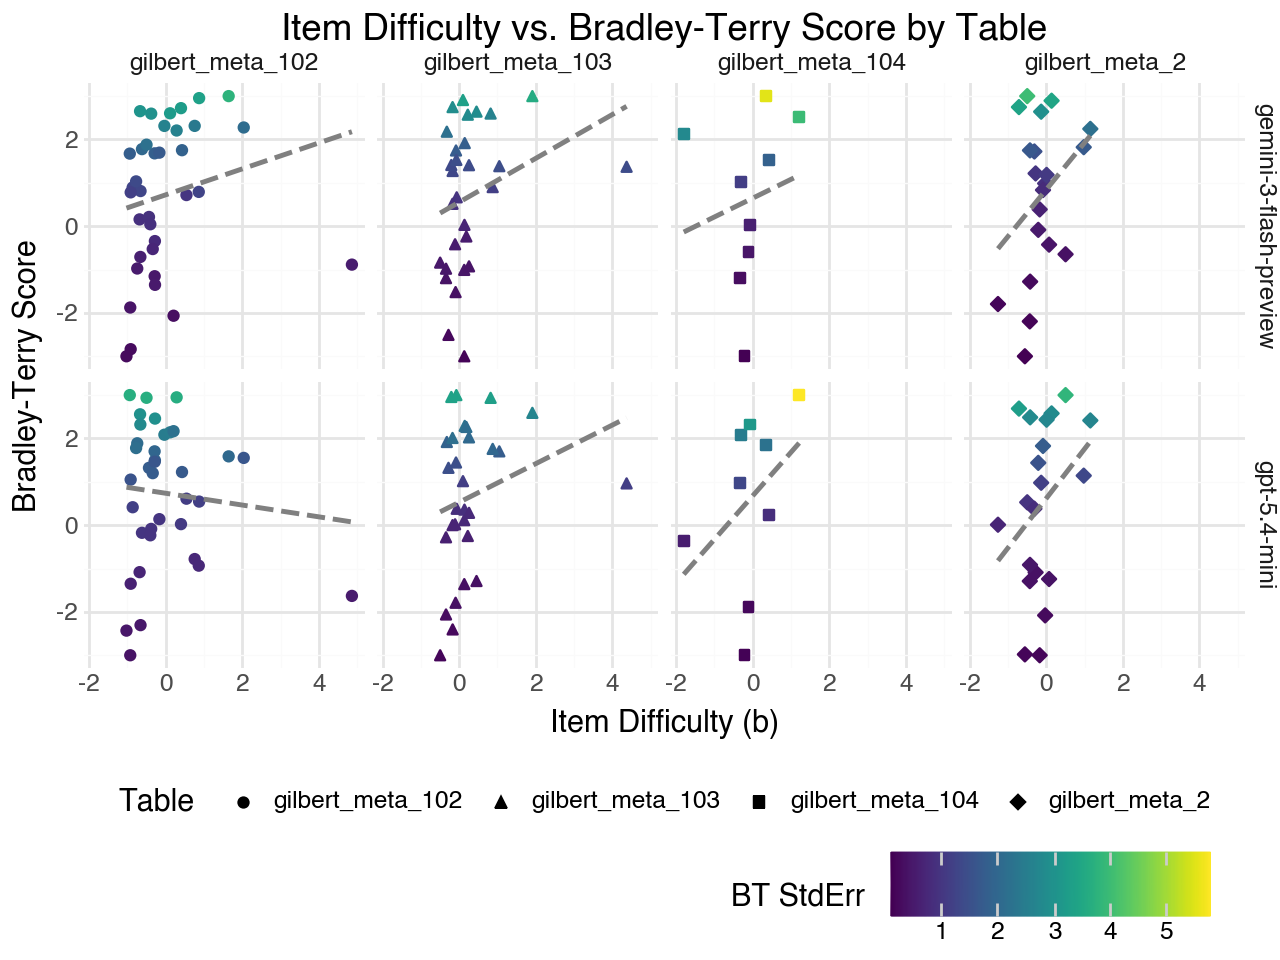

In [47]:
(
    ggplot(
        all_tables_item_scores_df_long,
        aes(
            x="b",
            y="score",
            shape="table",
            color="SE",
        ),
    )
    + geom_point()
    + geom_smooth(method="lm", se=False, linetype="dashed", color="gray")
    + facet_grid("model~table")
    + labs(title="Item Difficulty vs. Bradley-Terry Score by Table",
            x="Item Difficulty (b)",
            y="Bradley-Terry Score",
           shape="Table", 
           color="BT StdErr")
    + guides(
        shape=guide_legend(order=1),
        color=guide_colorbar(order=2, direction="horizontal"),
    )
    + theme_minimal()
    + theme(
        legend_position="bottom",
        legend_box="vertical",      # stack multiple legends
        legend_direction="horizontal",
    )
)

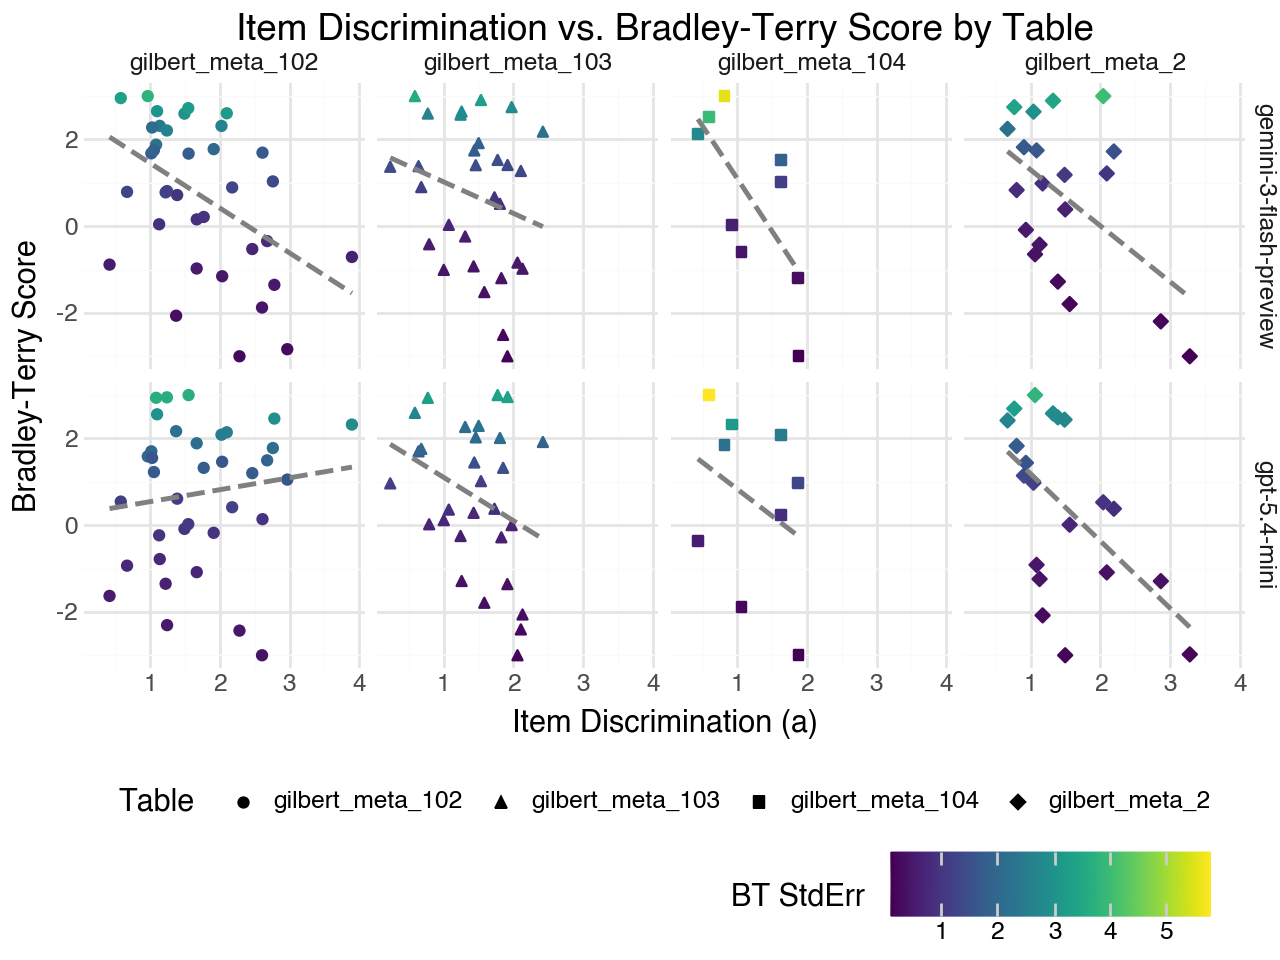

In [48]:
(
    ggplot(
        all_tables_item_scores_df_long,
        aes(
            x="a",
            y="score",
            shape="table",
            color="SE",
        ),
    )
    + geom_point()
    + geom_smooth(method="lm", se=False, linetype="dashed", color="gray")
    + facet_grid("model~table")
    + labs(title="Item Discrimination vs. Bradley-Terry Score by Table",
            x="Item Discrimination (a)",
            y="Bradley-Terry Score",
           shape="Table", 
           color="BT StdErr")
    + guides(
        shape=guide_legend(order=1),
        color=guide_colorbar(order=2, direction="horizontal"),
    )
    + theme_minimal()
    + theme(
        legend_position="bottom",
        legend_box="vertical",      # stack multiple legends
        legend_direction="horizontal",
    )
)

In [50]:
from scipy.stats import spearmanr
import numpy as np

def spearman_with_p(df, x_col="b", y_col="score"):
    xy = df[[x_col, y_col]].dropna()
    n = len(xy)
    if n < 3:
        return pd.Series({"spearman_corr": np.nan, "p_value": np.nan, "n": n})

    res = spearmanr(xy[x_col], xy[y_col], alternative="two-sided")
    return pd.Series(
        {
            "spearman_corr": res.statistic,
            "p_value": res.pvalue,
            "n": n,
        }
    )

correlations = (
    all_tables_item_scores_df_long
    .groupby(["table", "model"])
    .apply(spearman_with_p)
    .reset_index()
)

print(correlations)

              table                   model  spearman_corr   p_value     n
0  gilbert_meta_102  gemini-3-flash-preview       0.417503  0.011293  36.0
1  gilbert_meta_102            gpt-5.4-mini       0.060232  0.727125  36.0
2  gilbert_meta_103  gemini-3-flash-preview       0.354187  0.059418  29.0
3  gilbert_meta_103            gpt-5.4-mini       0.329064  0.081328  29.0
4  gilbert_meta_104  gemini-3-flash-preview       0.450000  0.224216   9.0
5  gilbert_meta_104            gpt-5.4-mini       0.433333  0.243952   9.0
6    gilbert_meta_2  gemini-3-flash-preview       0.224060  0.342286  20.0
7    gilbert_meta_2            gpt-5.4-mini       0.308271  0.186056  20.0


In [51]:
correlations = (
    all_tables_item_scores_df_long
    .groupby(["table", "model"])
    .apply(lambda df: spearman_with_p(df, x_col="a", y_col="score"))
    .reset_index()
)

print(correlations)

              table                   model  spearman_corr   p_value     n
0  gilbert_meta_102  gemini-3-flash-preview      -0.467181  0.004070  36.0
1  gilbert_meta_102            gpt-5.4-mini       0.092664  0.590907  36.0
2  gilbert_meta_103  gemini-3-flash-preview      -0.213793  0.265449  29.0
3  gilbert_meta_103            gpt-5.4-mini      -0.296059  0.118904  29.0
4  gilbert_meta_104  gemini-3-flash-preview      -0.800000  0.009628   9.0
5  gilbert_meta_104            gpt-5.4-mini      -0.366667  0.331740   9.0
6    gilbert_meta_2  gemini-3-flash-preview      -0.383459  0.095124  20.0
7    gilbert_meta_2            gpt-5.4-mini      -0.565414  0.009374  20.0


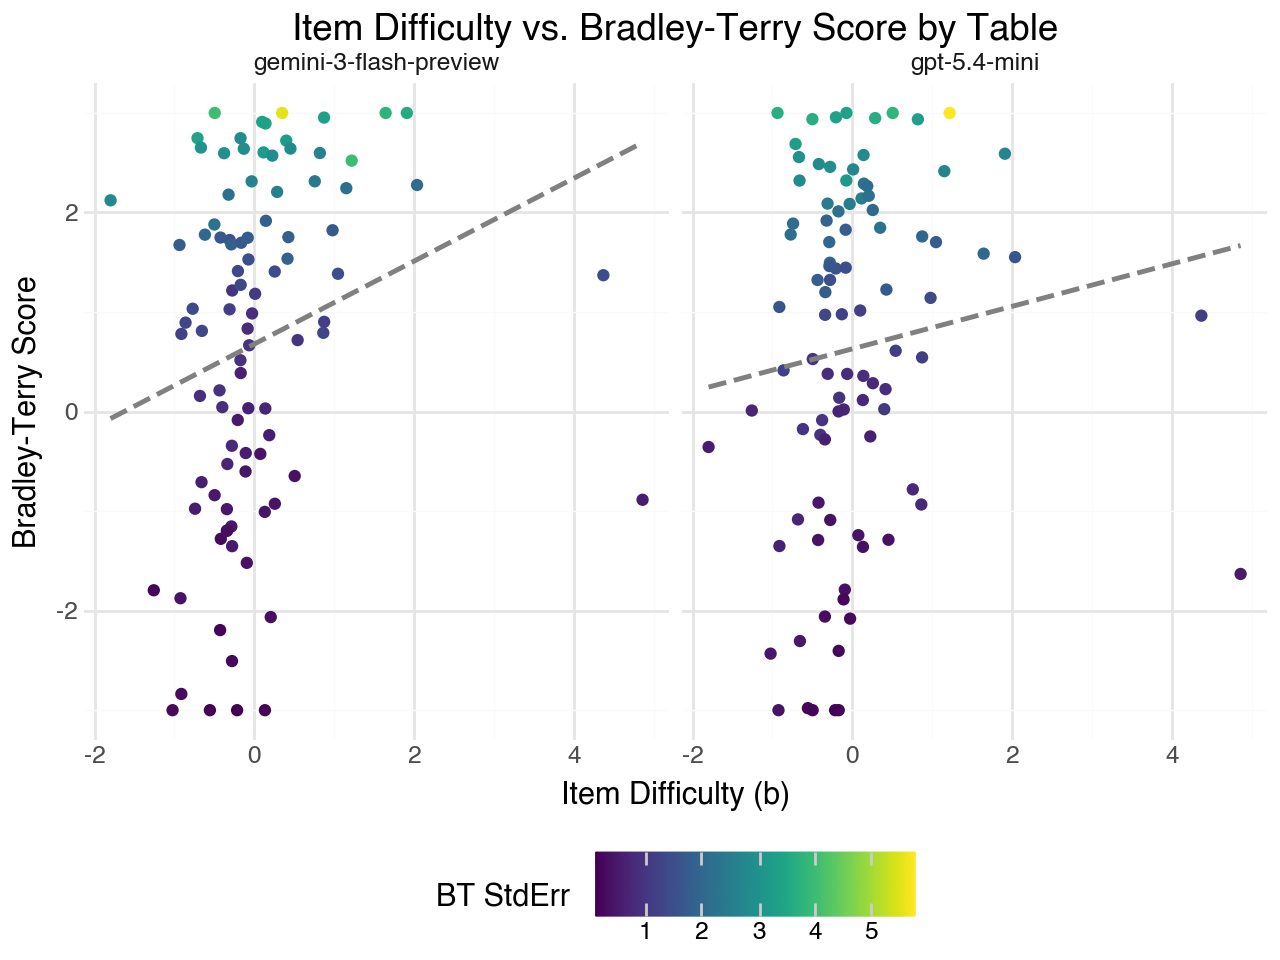

In [46]:
(
    ggplot(
        all_tables_item_scores_df_long,
        aes(
            x="b",
            y="score",
            # shape="table",
            color="SE",
        ),
    )
    + geom_point()
    + geom_smooth(method="lm", se=False, linetype="dashed", color="gray")
    + facet_grid("~model")
    + labs(title="Item Difficulty vs. Bradley-Terry Score by Table",
            x="Item Difficulty (b)",
            y="Bradley-Terry Score",
           shape="Table", 
           color="BT StdErr")
    + guides(
        shape=guide_legend(order=1),
        color=guide_colorbar(order=2, direction="horizontal"),
    )
    + theme_minimal()
    + theme(
        legend_position="bottom",
        legend_box="vertical",      # stack multiple legends
        legend_direction="horizontal",
    )
)

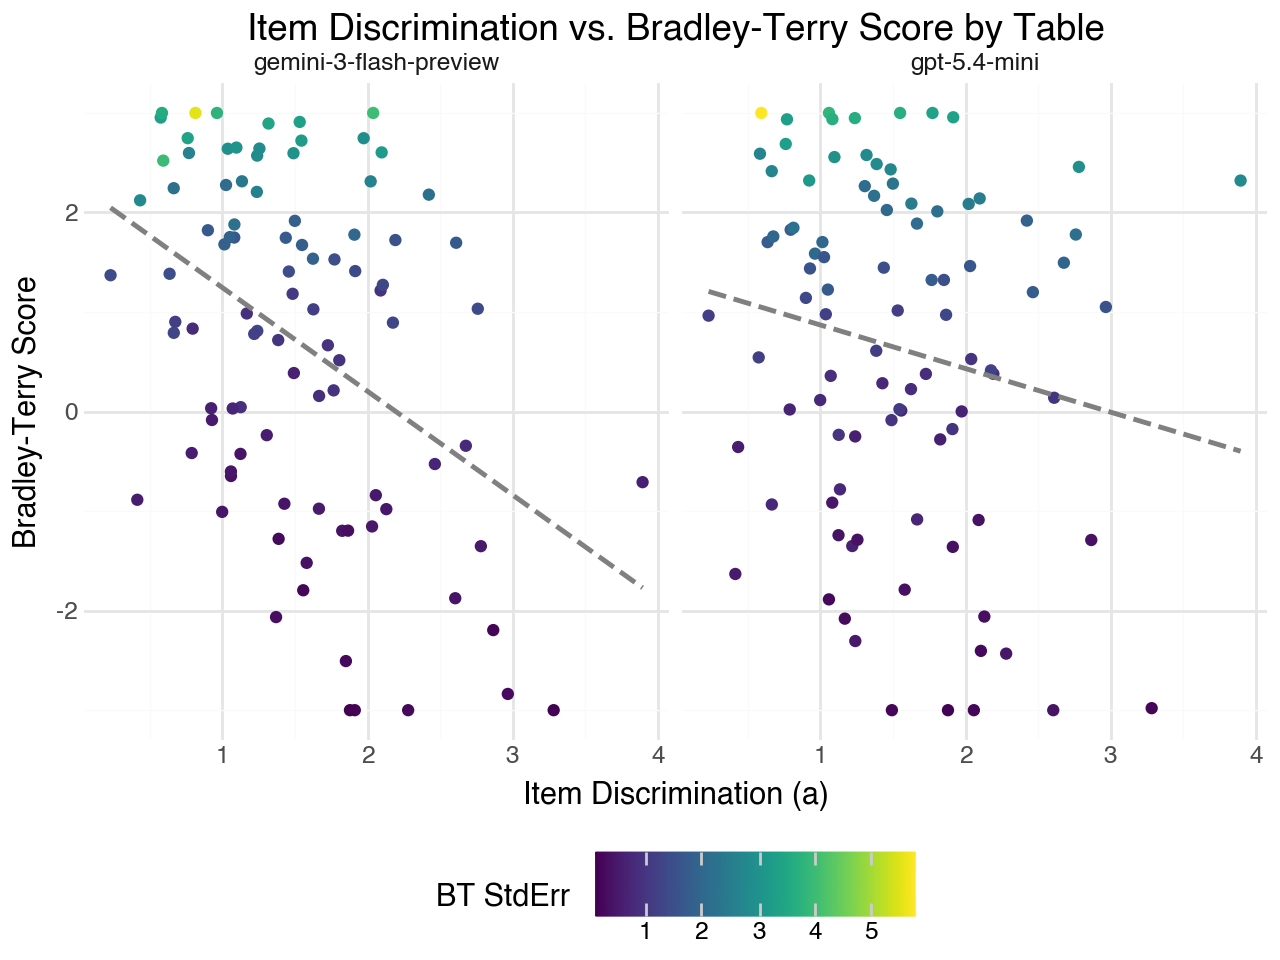

In [49]:
(
    ggplot(
        all_tables_item_scores_df_long,
        aes(
            x="a",
            y="score",
            # shape="table",
            color="SE",
        ),
    )
    + geom_point()
    + geom_smooth(method="lm", se=False, linetype="dashed", color="gray")
    + facet_grid("~model")
    + labs(title="Item Discrimination vs. Bradley-Terry Score by Table",
            x="Item Discrimination (a)",
            y="Bradley-Terry Score",
           shape="Table", 
           color="BT StdErr")
    + guides(
        shape=guide_legend(order=1),
        color=guide_colorbar(order=2, direction="horizontal"),
    )
    + theme_minimal()
    + theme(
        legend_position="bottom",
        legend_box="vertical",      # stack multiple legends
        legend_direction="horizontal",
    )
)

In [76]:
# Calculate the Spearman correlation and p-value for the entire dataset
overall_correlation = (
    all_tables_item_scores_df_long
    .groupby(["model"])
    .apply(spearman_with_p)
    .reset_index()
)

print(overall_correlation)

                    model  spearman_corr   p_value     n
0  gemini-3-flash-preview       0.343875  0.000690  94.0
1            gpt-5.4-mini       0.201539  0.051429  94.0


In [77]:
# Calculate the Spearman correlation and p-value for the entire dataset
overall_correlation_a = (
    all_tables_item_scores_df_long
    .groupby(["model"])
    .apply(lambda df: spearman_with_p(df, x_col="a", y_col="score"))
    .reset_index()
)

print(overall_correlation_a)

                    model  spearman_corr   p_value     n
0  gemini-3-flash-preview      -0.369560  0.000247  94.0
1            gpt-5.4-mini      -0.190253  0.066253  94.0


In [41]:
# Using all_tables_item_scores_df, calculate the Spearman correlation between the gemini-3-flash and gpt-5.4-mini
from sklearn.metrics import cohen_kappa_score
gemini_scores = all_tables_item_scores_df_long[all_tables_item_scores_df_long["model"] == "gemini-3-flash-preview"]["score"]
gpt54_scores = all_tables_item_scores_df_long[all_tables_item_scores_df_long["model"] == "gpt-5.4-mini"]["score"]
corr, p_value = spearmanr(gemini_scores, gpt54_scores)
print(f"Spearman correlation between Gemini 3 Flash Preview and GPT-5.4 Mini: {corr:.4f} (p-value: {p_value:.4f})")

Spearman correlation between Gemini 3 Flash Preview and GPT-5.4 Mini: 0.3391 (p-value: 0.0008)


# What the frick is happening

Claude's idea: 

This is a genuinely fascinating finding, and I think the inverse relationship is actually theoretically coherent once you unpack what each measure is capturing. Let me walk through what I think is happening.

## The Core Disconnect: Face Difficulty vs. Empirical Difficulty

Your LLM-generated BT scores and the IRT *b* parameter are measuring **fundamentally different things** that happen to be negatively correlated.

**What your CGCoT chain captures:** The LLM is doing content-apparent severity assessment — analyzing linguistic markers of demand: conditional logic, sophisticated vocabulary, multi-step reasoning, strong emotional language, conceptual abstraction. It's essentially asking "how demanding does this *look*?"

**What IRT *b* captures:** Empirical difficulty — the latent trait level at which a respondent has a 50% probability of correct/endorsed response, derived purely from how people *actually respond* in aggregate.

These diverge systematically, and here's why:

## Why the Inverse Relationship Emerges

**1. The "deceptively simple hard item" problem**

High-*b* items are often psychometrically hard *precisely because* they're linguistically simple but tap rare or extreme states. Consider:
- A depression item like *"I feel that life is not worth living"* has a high endorsement threshold (rare, high-severity), but an LLM analyzing it via CGCoT sees simple syntax and a direct behavioral statement — it would likely rate this *lower* on required trait level than a complex multi-part item.
- Cognitively, items like *"What is 2+2?"* are easy, but a tricky analogical reasoning item with complex syntax might look hard to an LLM yet empirically have a lower *b* if item structure gives away the answer.

**2. LLMs are implicitly calibrated to a modal respondent**

Your model has absorbed human writing that reflects typical experience. It lacks calibration on the *base rate scarcity* of extreme responses. An item requiring someone to endorse a highly unusual attitude or symptom frequency gets rated by the LLM relative to what seems linguistically/semantically demanding — not relative to how rarely that state occurs in a population.

**3. The CGCoT prompt chain may systematically reward elaboration**

Prompt 3 specifically asks about *structural and semantic elements* that increase cognitive load. Complex phrasing, tricky distractors, conditional logic — these are all more prevalent in lower-difficulty items that test constructors deliberately made nuanced. Simple, direct items (which are often the hardest symptom severity items) would produce less elaborate CoT outputs and thus lower BT scores in paired comparisons.

**4. Item discrimination (*a*) is invisible to the LLM**

In a 2PL model, *b* is entangled with *a*. An item with high *b* but low *a* is statistically hard but barely discriminating — it's not tapping the construct cleanly. The LLM has no access to response data, so it can't detect whether an item is poorly discriminating. This adds noise and could systematically distort the relationship.

## What the Standard Error Color Coding Tells You

In Image 1, the yellow/green dots (high BT StdErr) cluster at high BT scores / low IRT *b*. This is meaningful: the LLM is **most uncertain** about easy items. This makes sense — easy items may be more semantically ambiguous about which of a pair is "harder," whereas genuinely extreme-demand items (which the LLM rates as high-trait-requiring) likely produce more decisive comparisons.

## What This Actually Means for Your Study

Rather than invalidating the approach, I'd argue this finding is **a validity result in itself**. Your LLM BT scores appear to be measuring something real — call it **content-apparent severity** or **face validity of difficulty** — which is:

- A legitimate construct in item development (items rated as harder by SMEs/LLMs are often *easier* psychometrically because test constructors front-load complexity)
- Potentially useful for flagging construct-irrelevant variance (items that look hard but aren't, or vice versa, are candidates for revision)
- A complementary signal to IRT parameters, not a substitute

The key implication: if you want LLM BT scores to predict IRT *b*, you'd need to redesign the prompting to somehow incorporate base-rate reasoning or force the model to reason about *response likelihood* rather than *content demand*. Something like asking "for what proportion of the target population would this item represent a threshold they could barely cross?" pushes it closer to the *b* parameter's logic.

## A Testable Prediction

If this interpretation is right, you'd expect the inverse relationship to be **stronger for symptom/attitude scales** (where high-*b* items are extreme but linguistically simple) than for **cognitive ability tests** (where hard items often genuinely are more structurally complex). Does that split emerge in your 6 datasets?

# Remove outliers and re-run the correlation

In [58]:
all_tables_item_scores_df_long_filtered = all_tables_item_scores_df_long[
    all_tables_item_scores_df_long['b'] < 3
].copy()

print(all_tables_item_scores_df_long_filtered.shape)
all_tables_item_scores_df_long_filtered.head(3)

(184, 12)


,item,table,a,b,model,CGCoT_Breakdown_gemini-3-flash-preview,CGCoT_Breakdown_gpt-5.4-mini,combined_text,item_text,section_prompt,score,SE
0,20,gilbert_meta_2,2.039108,-0.495678,gemini-3-flash-preview,Original Text: Teacher Directions to Read Alou...,Original Text: Teacher Directions to Read Alou...,Teacher Directions to Read Aloud: “Now you wil...,What is similar about the work that paleontolo...,Teacher Directions to Read Aloud: “Now you wil...,3.000000,4.003638
1,20,gilbert_meta_2,2.039108,-0.495678,gpt-5.4-mini,Original Text: Teacher Directions to Read Alou...,Original Text: Teacher Directions to Read Alou...,Teacher Directions to Read Aloud: “Now you wil...,What is similar about the work that paleontolo...,Teacher Directions to Read Aloud: “Now you wil...,0.527728,0.958699
2,15,gilbert_meta_2,3.282003,-0.556399,gemini-3-flash-preview,Original Text: Teacher Directions to Read Alou...,Original Text: Teacher Directions to Read Alou...,Teacher Directions to Read Aloud: “Now you wil...,"According to the passage, who uses clues to fi...",Teacher Directions to Read Aloud: “Now you wil...,-3.000000,0.109184


In [59]:
# Correlations for a
correlations_filtered = (
    all_tables_item_scores_df_long_filtered
    .groupby(["table", "model"])
    .apply(lambda df: spearman_with_p(df, x_col="a", y_col="score"))
    .reset_index()
)

print(correlations_filtered)

# Correlations for b
correlations_filtered_b = (
    all_tables_item_scores_df_long_filtered
    .groupby(["table", "model"])
    .apply(lambda df: spearman_with_p(df, x_col="b", y_col="score"))
    .reset_index()
)
print(correlations_filtered_b)

              table                   model  spearman_corr   p_value     n
0  gilbert_meta_102  gemini-3-flash-preview      -0.546218  0.000688  35.0
1  gilbert_meta_102            gpt-5.4-mini       0.031933  0.855503  35.0
2  gilbert_meta_103  gemini-3-flash-preview      -0.220033  0.260556  28.0
3  gilbert_meta_103            gpt-5.4-mini      -0.318008  0.099117  28.0
4  gilbert_meta_104  gemini-3-flash-preview      -0.800000  0.009628   9.0
5  gilbert_meta_104            gpt-5.4-mini      -0.366667  0.331740   9.0
6    gilbert_meta_2  gemini-3-flash-preview      -0.383459  0.095124  20.0
7    gilbert_meta_2            gpt-5.4-mini      -0.565414  0.009374  20.0
              table                   model  spearman_corr   p_value     n
0  gilbert_meta_102  gemini-3-flash-preview       0.495518  0.002472  35.0
1  gilbert_meta_102            gpt-5.4-mini       0.128011  0.463654  35.0
2  gilbert_meta_103  gemini-3-flash-preview       0.366174  0.055310  28.0
3  gilbert_meta_103      

In [60]:
# Correlations for a
correlations_filtered = (
    all_tables_item_scores_df_long_filtered
    .groupby(["model"])
    .apply(lambda df: spearman_with_p(df, x_col="a", y_col="score"))
    .reset_index()
)

print(correlations_filtered)

# Correlations for b
correlations_filtered_b = (
    all_tables_item_scores_df_long_filtered
    .groupby(["model"])
    .apply(lambda df: spearman_with_p(df, x_col="b", y_col="score"))
    .reset_index()
)
print(correlations_filtered_b)

                    model  spearman_corr   p_value     n
0  gemini-3-flash-preview      -0.397870  0.000086  92.0
1            gpt-5.4-mini      -0.223766  0.032016  92.0
                    model  spearman_corr   p_value     n
0  gemini-3-flash-preview       0.371813  0.000263  92.0
1            gpt-5.4-mini       0.235912  0.023580  92.0


In [63]:
overall_correlation

,model,spearman_corr,p_value,n
0,gemini-3-flash-preview,-0.369560,0.000247,94.0
1,gpt-5.4-mini,-0.190253,0.066253,94.0


In [78]:
pd.concat([overall_correlation_a.reset_index(drop=True),
           correlations_filtered.reset_index(drop=True),
           overall_correlation.reset_index(drop=True),
           correlations_filtered_b.reset_index(drop=True), 
           ], 
           keys=["orig_a", "a_filtered", "orig_b", "b_filtered"], 
           names=["parameter"])

model  spearman_corr   p_value     n
parameter                                                          
orig_a     0  gemini-3-flash-preview      -0.369560  0.000247  94.0
           1            gpt-5.4-mini      -0.190253  0.066253  94.0
a_filtered 0  gemini-3-flash-preview      -0.397870  0.000086  92.0
           1            gpt-5.4-mini      -0.223766  0.032016  92.0
orig_b     0  gemini-3-flash-preview       0.343875  0.000690  94.0
           1            gpt-5.4-mini       0.201539  0.051429  94.0
b_filtered 0  gemini-3-flash-preview       0.371813  0.000263  92.0
           1            gpt-5.4-mini       0.235912  0.023580  92.0

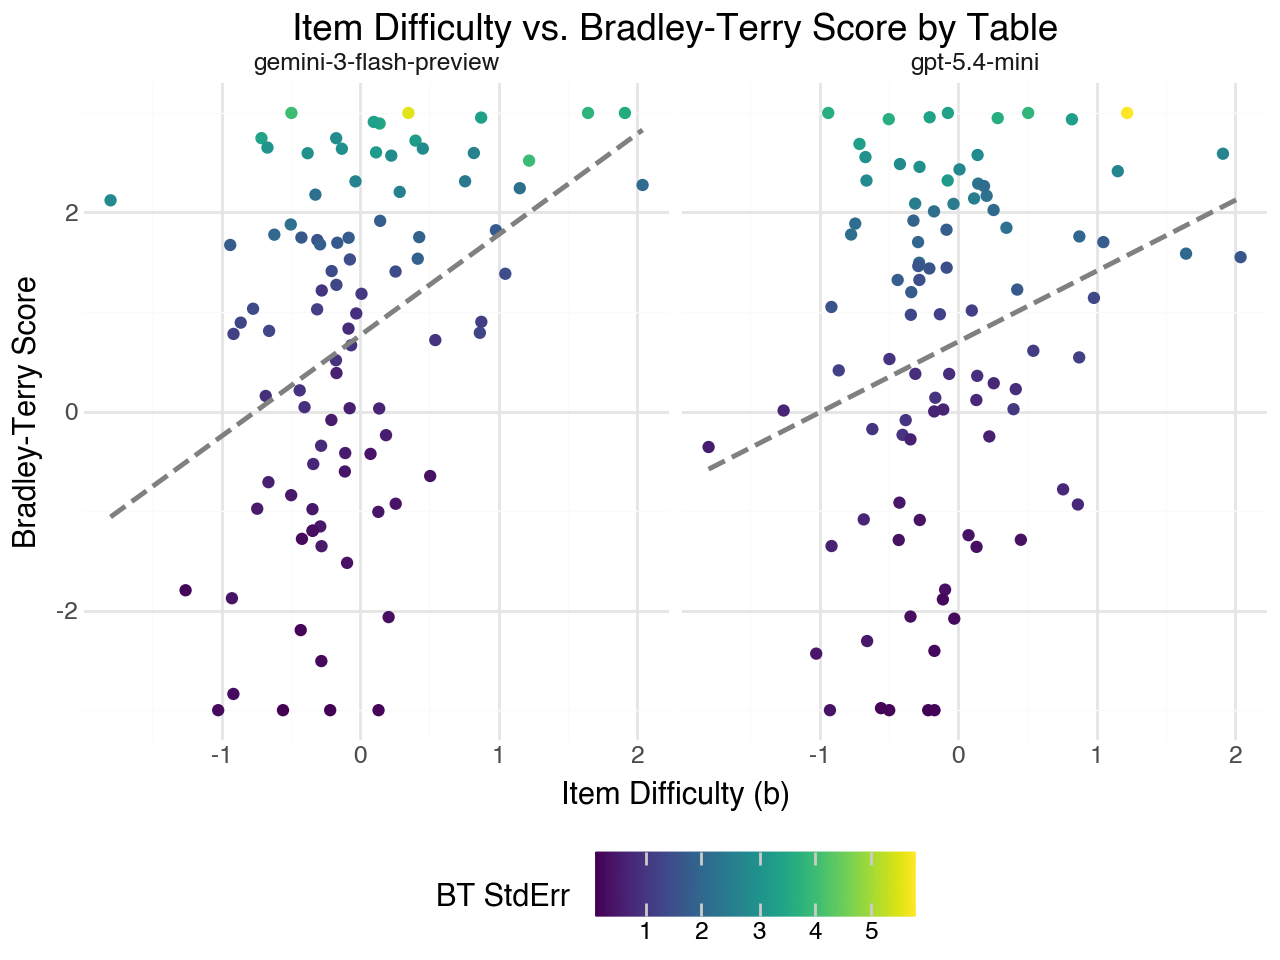

In [70]:
(
    ggplot(
        all_tables_item_scores_df_long_filtered,
        aes(
            x="b",
            y="score",
            # shape="table",
            color="SE",
        ),
    )
    + geom_point()
    + geom_smooth(method="lm", se=False, linetype="dashed", color="gray")
    + facet_grid("~model")
    + labs(title="Item Difficulty vs. Bradley-Terry Score by Table",
            x="Item Difficulty (b)",
            y="Bradley-Terry Score",
           shape="Table", 
           color="BT StdErr")
    + guides(
        shape=guide_legend(order=1),
        color=guide_colorbar(order=2, direction="horizontal"),
    )
    + theme_minimal()
    + theme(
        legend_position="bottom",
        legend_box="vertical",      # stack multiple legends
        legend_direction="horizontal",
    )
)

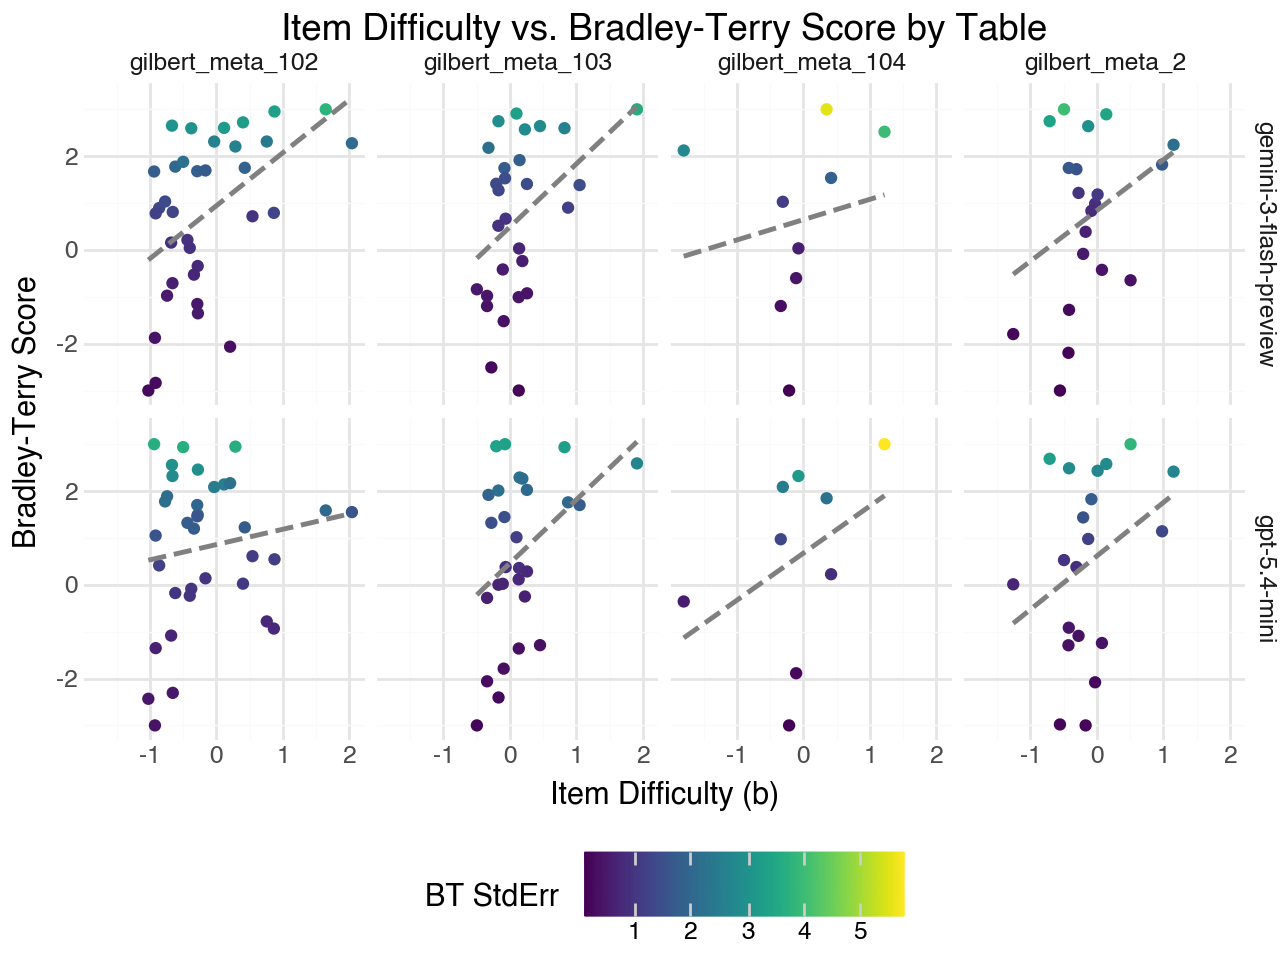

In [75]:
(
    ggplot(
        all_tables_item_scores_df_long_filtered,
        aes(
            x="b",
            y="score",
            # shape="table",
            color="SE",
        ),
    )
    + geom_point()
    + geom_smooth(method="lm", se=False, linetype="dashed", color="gray")
    + facet_grid("model~table")
    + labs(title="Item Difficulty vs. Bradley-Terry Score by Table",
            x="Item Difficulty (b)",
            y="Bradley-Terry Score",
           shape="Table", 
           color="BT StdErr")
    + guides(
        shape=guide_legend(order=1),
        color=guide_colorbar(order=2, direction="horizontal"),
    )
    + theme_minimal()
    + theme(
        legend_position="bottom",
        legend_box="vertical",      # stack multiple legends
        legend_direction="horizontal",
    )
)

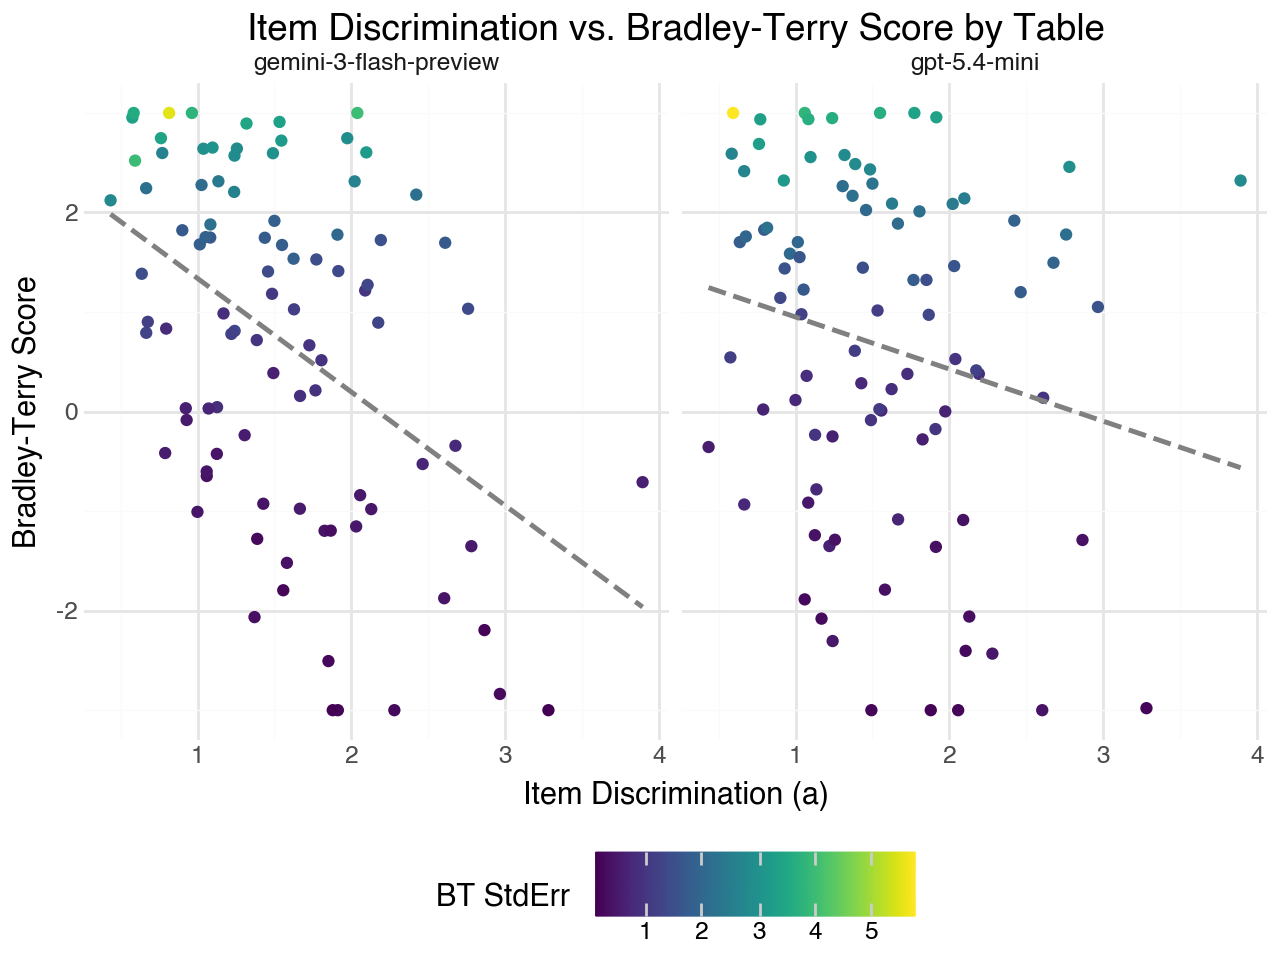

In [71]:
(
    ggplot(
        all_tables_item_scores_df_long_filtered,
        aes(
            x="a",
            y="score",
            # shape="table",
            color="SE",
        ),
    )
    + geom_point()
    + geom_smooth(method="lm", se=False, linetype="dashed", color="gray")
    + facet_grid("~model")
    + labs(title="Item Discrimination vs. Bradley-Terry Score by Table",
            x="Item Discrimination (a)",
            y="Bradley-Terry Score",
           shape="Table", 
           color="BT StdErr")
    + guides(
        shape=guide_legend(order=1),
        color=guide_colorbar(order=2, direction="horizontal"),
    )
    + theme_minimal()
    + theme(
        legend_position="bottom",
        legend_box="vertical",      # stack multiple legends
        legend_direction="horizontal",
    )
)

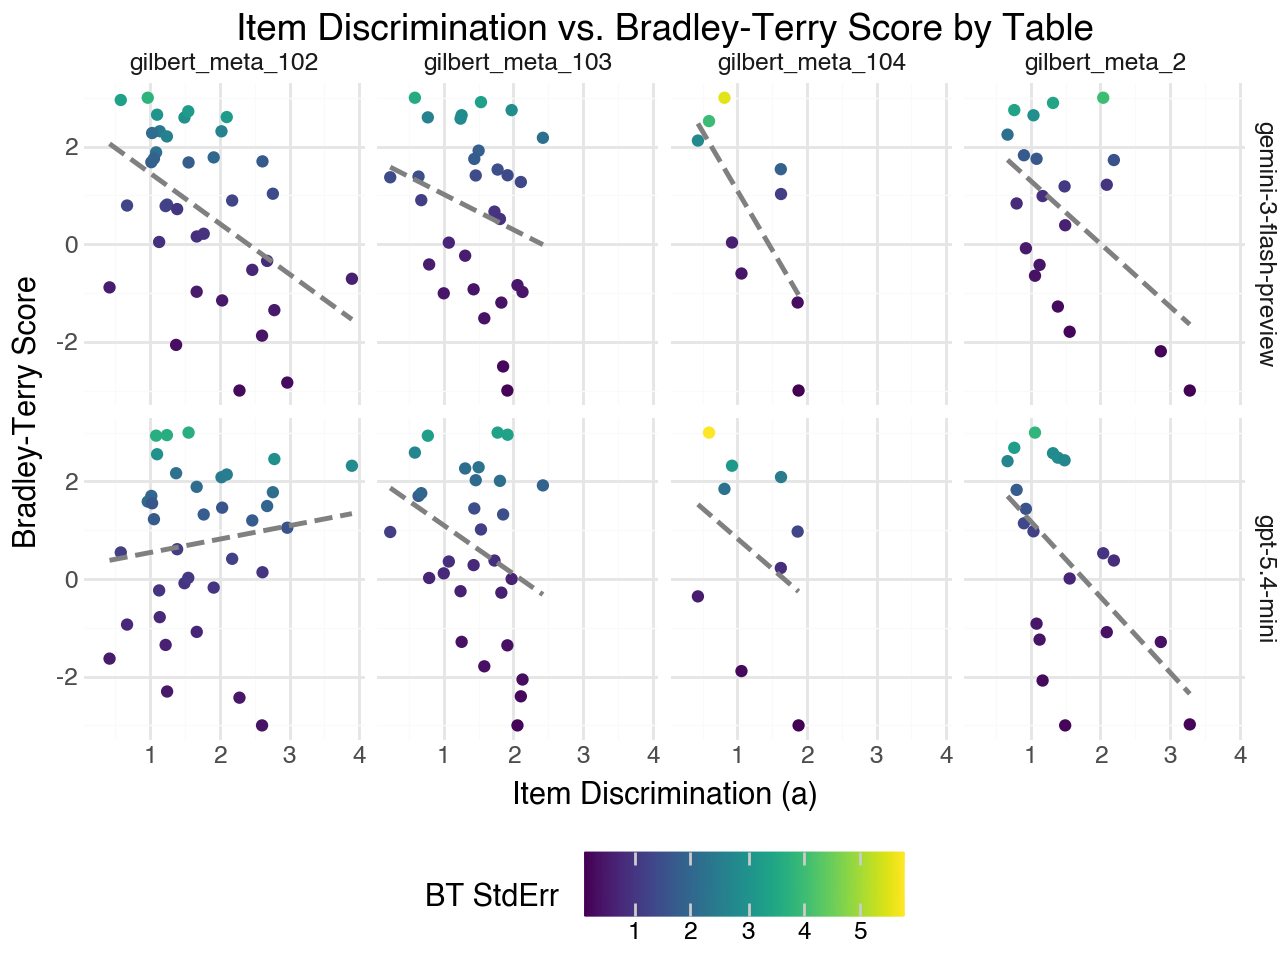

In [74]:
(
    ggplot(
        all_tables_item_scores_df_long,
        aes(
            x="a",
            y="score",
            # shape="table",
            color="SE",
        ),
    )
    + geom_point()
    + geom_smooth(method="lm", se=False, linetype="dashed", color="gray")
    + facet_grid("model~table")
    + labs(title="Item Discrimination vs. Bradley-Terry Score by Table",
            x="Item Discrimination (a)",
            y="Bradley-Terry Score",
           shape="Table", 
           color="BT StdErr")
    + guides(
        shape=guide_legend(order=1),
        color=guide_colorbar(order=2, direction="horizontal"),
    )
    + theme_minimal()
    + theme(
        legend_position="bottom",
        legend_box="vertical",      # stack multiple legends
        legend_direction="horizontal",
    )
)

# Ability?

In [89]:
base_dir = "../results/edu_first_runs"
# Add base_dir to the beginning of the paths in DIRECTORIES
PATHS = [f"{base_dir}/{dir}" for dir in DIRECTORIES]

all_thetas_dfs = []
for path in PATHS:
    dir = DIRECTORIES[PATHS.index(path)]
    df = pd.read_csv(f"{path}/{dir}_irt_persons.csv")
    df['table'] = dir  # Add a column for the table name
    all_thetas_dfs.append(df)
    print(f"Appended {path}/{dir}_irt_persons.csv. Shape: {df.shape}")

all_thetas = pd.concat(all_thetas_dfs, ignore_index=True)
print(f"Concatenated all thetas. Shape: {all_thetas.shape}")

Appended ../results/edu_first_runs/gilbert_meta_2/gilbert_meta_2_irt_persons.csv. Shape: (2174, 4)
Appended ../results/edu_first_runs/gilbert_meta_102/gilbert_meta_102_irt_persons.csv. Shape: (1914, 4)
Appended ../results/edu_first_runs/gilbert_meta_103/gilbert_meta_103_irt_persons.csv. Shape: (1914, 4)
Appended ../results/edu_first_runs/gilbert_meta_104/gilbert_meta_104_irt_persons.csv. Shape: (1914, 4)
Concatenated all thetas. Shape: (7916, 4)


In [ ]:
all_thetas

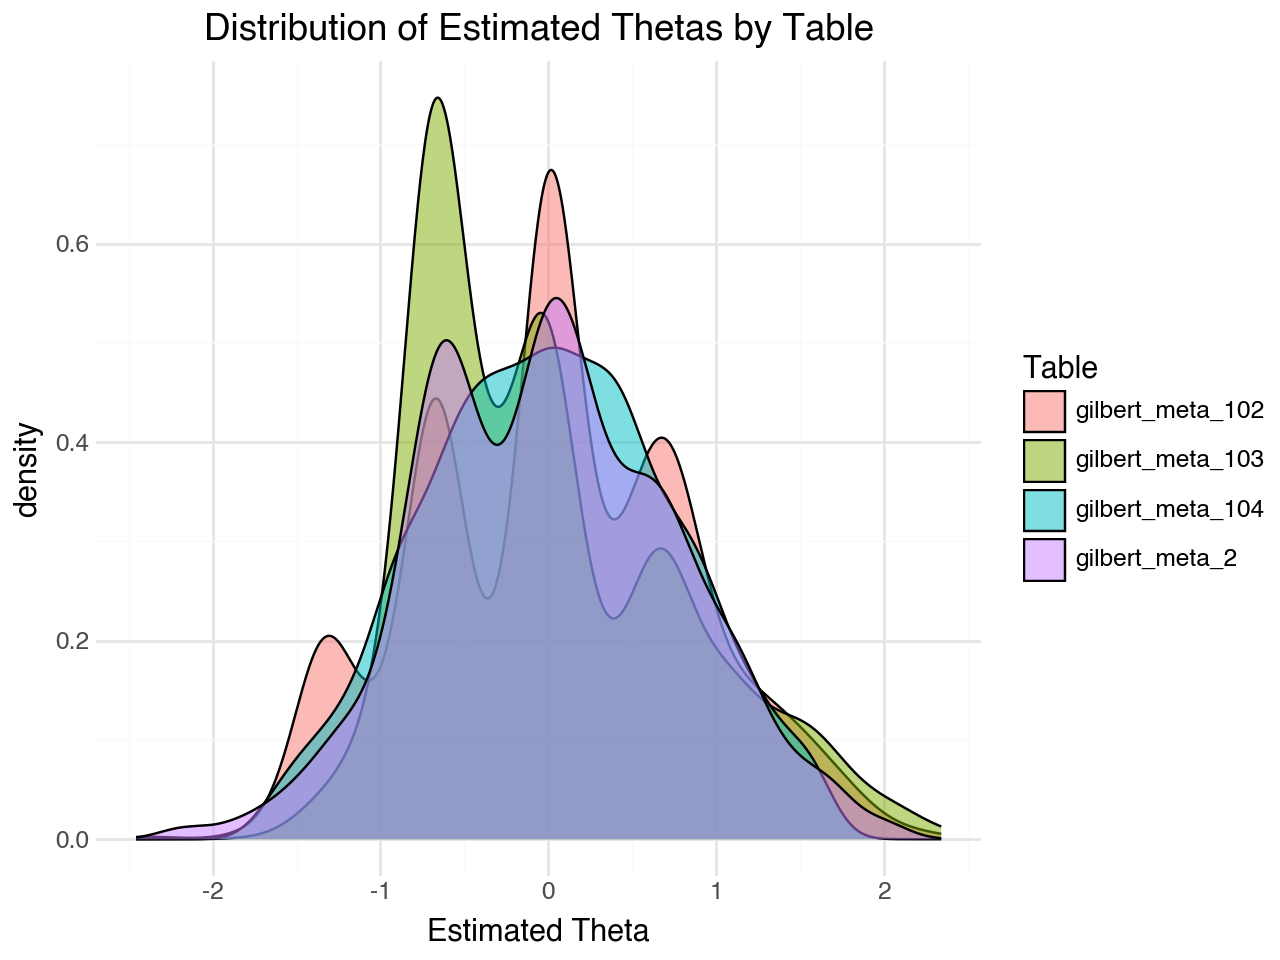

In [92]:
(
    ggplot(all_thetas, 
           aes(x="theta", fill="table")) +
           geom_density(alpha=0.5) +
           labs(title="Distribution of Estimated Thetas by Table",
                x="Estimated Theta",
                fill="Table") +
           theme_minimal()
)